# Iris Dataset - Exploratory Data Analysis (EDA)

## Problem Statement

The Iris dataset contains measurements for 150 iris flowers from three species: *Iris setosa*, *Iris versicolor*, and *Iris virginica*. The goal of this EDA is to understand the distribution of features (sepal length, sepal width, petal length, petal width), identify patterns and relationships between features, detect outliers, and determine how well the features can distinguish between species. This analysis lays the groundwork for building classification models.

## 1. Install & Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

## 2. Load the Dataset

In [2]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Data Inspection

In [3]:
iris.shape

(150, 5)

In [4]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
iris.duplicated().sum()

np.int64(1)

In [8]:
iris['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 4. Aggregations & GroupBy

In [9]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [10]:
iris.groupby('species').std()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


In [11]:
iris.groupby('species').agg(['min', 'max'])

sepal_length      sepal_width      petal_length      petal_width  \
                    min  max         min  max          min  max         min   
species                                                                       
setosa              4.3  5.8         2.3  4.4          1.0  1.9         0.1   
versicolor          4.9  7.0         2.0  3.4          3.0  5.1         1.0   
virginica           4.9  7.9         2.2  3.8          4.5  6.9         1.4   

                 
            max  
species          
setosa      0.6  
versicolor  1.8  
virginica   2.5

In [12]:
iris.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


### 4.2 Named Aggregations

Using Pandas Named Aggregations (`agg()`), I assign custom and descriptive column names directly to my aggregated output, rather than keeping the default column names or dealing with multi-level column indexes.

In [13]:
# Named aggregation for species-specific metrics
named_agg_df = iris.groupby('species').agg(
    mean_sepal_length=('sepal_length', 'mean'),
    std_sepal_length=('sepal_length', 'std'),
    median_petal_length=('petal_length', 'median'),
    max_petal_width=('petal_width', 'max'),
    sample_count=('species', 'count')
)
named_agg_df

,mean_sepal_length,std_sepal_length,median_petal_length,max_petal_width,sample_count
species,,,,,
setosa,5.006,0.352490,1.50,0.6,50
versicolor,5.936,0.516171,4.35,1.8,50
virginica,6.588,0.635880,5.55,2.5,50


### 4.3 Aggregations & Group Spread

I can analyze group-specific statistics such as the total range (maximum - minimum), variance, and skewness of flower features to better understand the spread of the data.

In [14]:
# Custom aggregate functions (Range, Variance, Skewness)
custom_agg_df = iris.groupby('species').agg(
    sepal_length_range=('sepal_length', lambda x: x.max() - x.min()),
    sepal_width_variance=('sepal_width', 'var'),
    petal_length_skewness=('petal_length', lambda x: x.skew()),
    petal_width_kurtosis=('petal_width', lambda x: x.kurt())
)
custom_agg_df

,sepal_length_range,sepal_width_variance,petal_length_skewness,petal_width_kurtosis
species,,,,
setosa,1.5,0.143690,0.106394,1.719130
versicolor,2.1,0.098469,-0.606508,-0.410059
virginica,3.0,0.104004,0.549445,-0.602264


### 4.4 GroupBy Binning and Composition Analysis

Grouping by a continuous feature is possible by first segmenting (binning) it. Below, I categorize sepal length into `Short`, `Medium`, and `Long` bins, and cross-tabulate it with `species` to see the distribution of sizes across species.

In [15]:
# Bin sepal length into custom categories
iris_binned = iris.copy()
iris_binned['sepal_length_cat'] = pd.cut(
    iris_binned['sepal_length'], 
    bins=[0, 5.2, 6.3, float('inf')], 
    labels=['Short (<5.2cm)', 'Medium (5.2-6.3cm)', 'Long (>6.3cm)']
)

# Cross-tabulate species and sepal length category
crosstab_df = pd.crosstab(
    index=iris_binned['species'], 
    columns=iris_binned['sepal_length_cat'],
    normalize='index'  # Show percentage distribution per species
) * 100

crosstab_df.round(2).rename_axis('Sepal Length Category', axis=1)

Sepal Length Category,Short (<5.2cm),Medium (5.2-6.3cm),Long (>6.3cm)
species,,,
setosa,78.0,22.0,0.0
versicolor,10.0,68.0,22.0
virginica,2.0,36.0,62.0


### 4.5 Species-Specific Correlation Matrices

Running correlation globally on the dataset might mask relationships that are unique to each species. By grouping by species, we can compute correlation matrices for each subset of flowers to see how feature dependencies differ across them.

In [16]:
# Groupby and calculate within-group feature correlations
group_correlations = iris.groupby('species')[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].corr()
group_correlations

sepal_length  sepal_width  petal_length  petal_width
species                                                                      
setosa     sepal_length      1.000000     0.742547      0.267176     0.278098
           sepal_width       0.742547     1.000000      0.177700     0.232752
           petal_length      0.267176     0.177700      1.000000     0.331630
           petal_width       0.278098     0.232752      0.331630     1.000000
versicolor sepal_length      1.000000     0.525911      0.754049     0.546461
           sepal_width       0.525911     1.000000      0.560522     0.663999
           petal_length      0.754049     0.560522      1.000000     0.786668
           petal_width       0.546461     0.663999      0.786668     1.000000
virginica  sepal_length      1.000000     0.457228      0.864225     0.281108
           sepal_width       0.457228     1.000000      0.401045     0.537728
           petal_length      0.864225     0.401045      1.000000     0.322108
           petal_width       0.281108     0.537728      0.322108     1.000000

### 4.6 Multi-Metric Pivot Tables

Using Pandas `pivot_table`, we can synthesize multi-dimensional reports. Here we look at the mean and sample count of both `petal_length` and `petal_width` grouped by both species and binned sepal length categories.

In [17]:
# Pivot table of petal measurements across species and binned sepal length
pivot_table_df = pd.pivot_table(
    iris_binned, 
    values=['petal_length', 'petal_width'],
    index='species',
    columns='sepal_length_cat',
    aggfunc=['mean', 'count'],
    observed=False
)
pivot_table_df

mean                                   \
                   petal_length                                    
sepal_length_cat Short (<5.2cm) Medium (5.2-6.3cm) Long (>6.3cm)   
species                                                            
setosa                  1.45641           1.481818           NaN   
versicolor              3.40000           4.267647      4.627273   
virginica               4.50000           5.166667      5.809677   

                                                                  \
                    petal_width                                    
sepal_length_cat Short (<5.2cm) Medium (5.2-6.3cm) Long (>6.3cm)   
species                                                            
setosa                 0.235897           0.281818           NaN   
versicolor             1.100000           1.320588      1.445455   
virginica              1.700000           1.916667      2.100000   

                          count                                   \
                   petal_length                                    
sepal_length_cat Short (<5.2cm) Medium (5.2-6.3cm) Long (>6.3cm)   
species                                                            
setosa                       39                 11             0   
versicolor                    5                 34            11   
virginica                     1                 18            31   

                                                                  
                    petal_width                                   
sepal_length_cat Short (<5.2cm) Medium (5.2-6.3cm) Long (>6.3cm)  
species                                                           
setosa                       39                 11             0  
versicolor                    5                 34            11  
virginica                     1                 18            31

## 5. Visualizations

### 5.1 Histograms - Feature Distributions

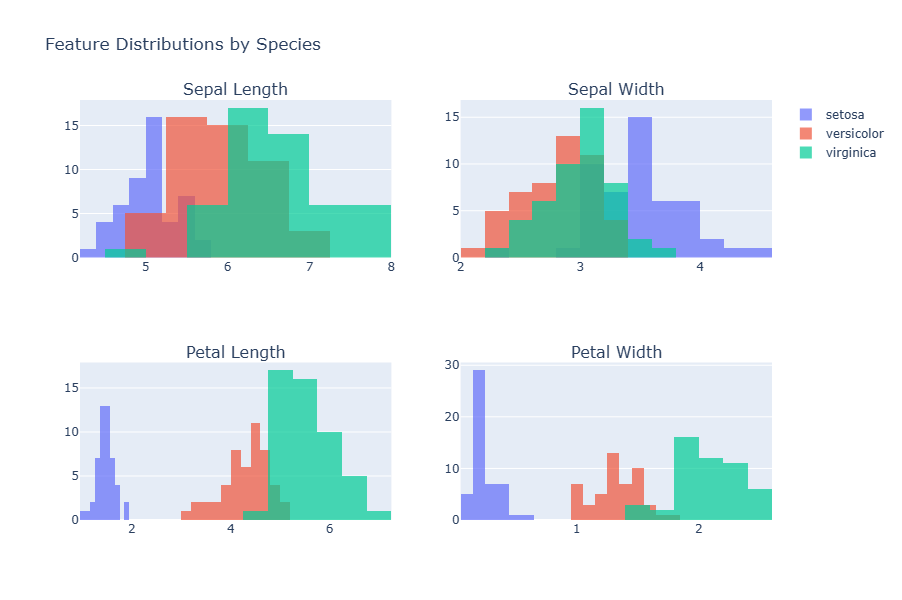

In [18]:
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=('Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width'))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
positions = [(1,1), (1,2), (2,1), (2,2)]
colors = ['#636EFA', '#EF553B', '#00CC96']

for feat, (r, c) in zip(features, positions):
    for species, color in zip(iris['species'].unique(), colors):
        subset = iris[iris['species'] == species]
        fig.add_trace(go.Histogram(x=subset[feat], name=species,
                                   opacity=0.7, marker_color=color, showlegend=(r==1 and c==1)),
                      row=r, col=c)

fig.update_layout(height=600, width=900, title_text='Feature Distributions by Species', barmode='overlay')
fig.show()

### 5.2 Boxplots - Outlier Detection & Spread

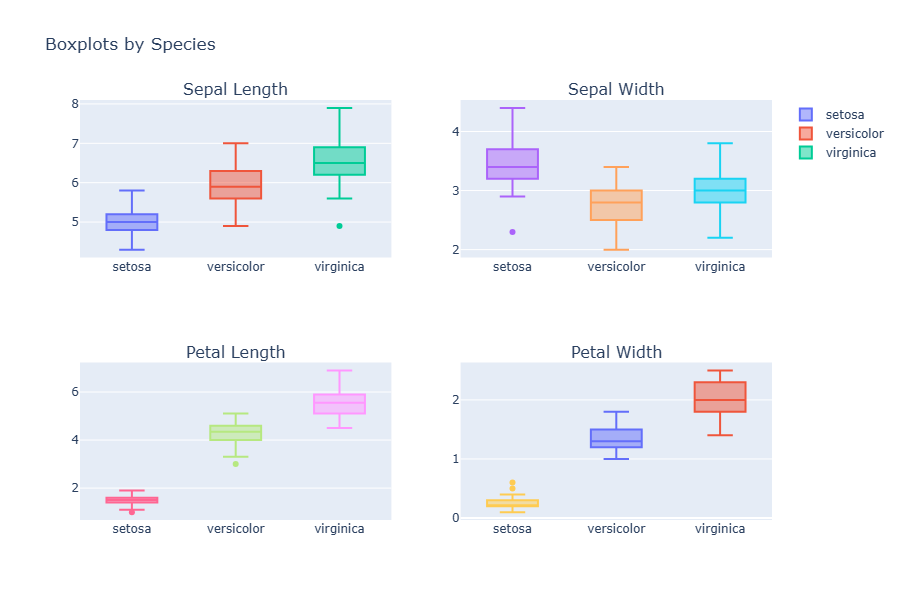

In [19]:
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=('Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width'))

for feat, (r, c) in zip(features, positions):
    for species in iris['species'].unique():
        subset = iris[iris['species'] == species]
        fig.add_trace(go.Box(y=subset[feat], name=species, showlegend=(r==1 and c==1)),
                      row=r, col=c)

fig.update_layout(height=600, width=900, title_text='Boxplots by Species')
fig.show()

### 5.3 Bar Chart - Mean Feature Values by Species

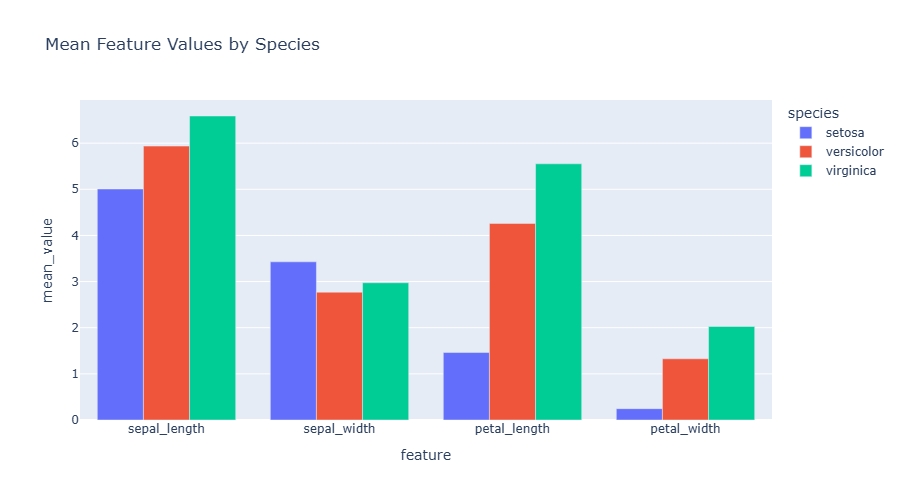

In [20]:
mean_df = iris.groupby('species').mean().reset_index().melt(id_vars='species', var_name='feature', value_name='mean_value')

fig = px.bar(mean_df, x='feature', y='mean_value', color='species', barmode='group',
             title='Mean Feature Values by Species')
fig.update_layout(height=500, width=900)
fig.show()

### 5.4 Heatmap - Correlation Matrix

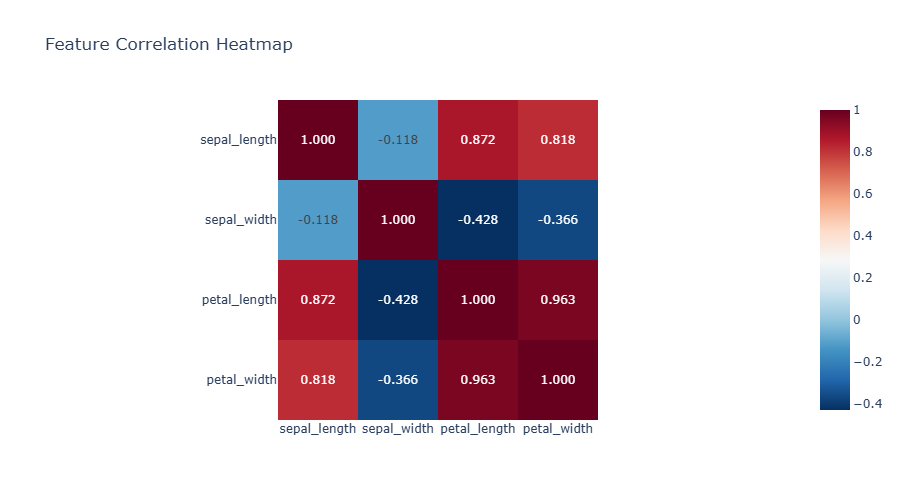

In [21]:
corr = iris.drop(columns='species').corr()

fig = px.imshow(corr, text_auto='.3f', color_continuous_scale='RdBu_r',
                title='Feature Correlation Heatmap')
fig.update_layout(height=500, width=600)
fig.show()

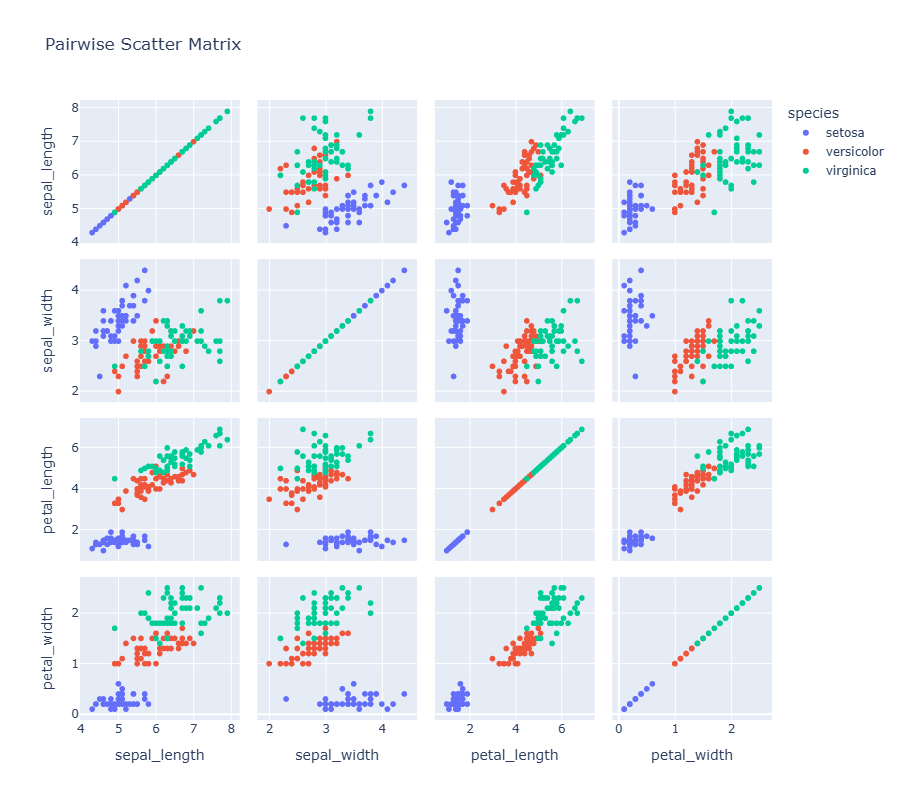

In [22]:
fig = px.scatter_matrix(iris, dimensions=features, color='species',
                        title='Pairwise Scatter Matrix')
fig.update_layout(height=800, width=900)
fig.show()

### 5.5 Pair Plot (Seaborn)

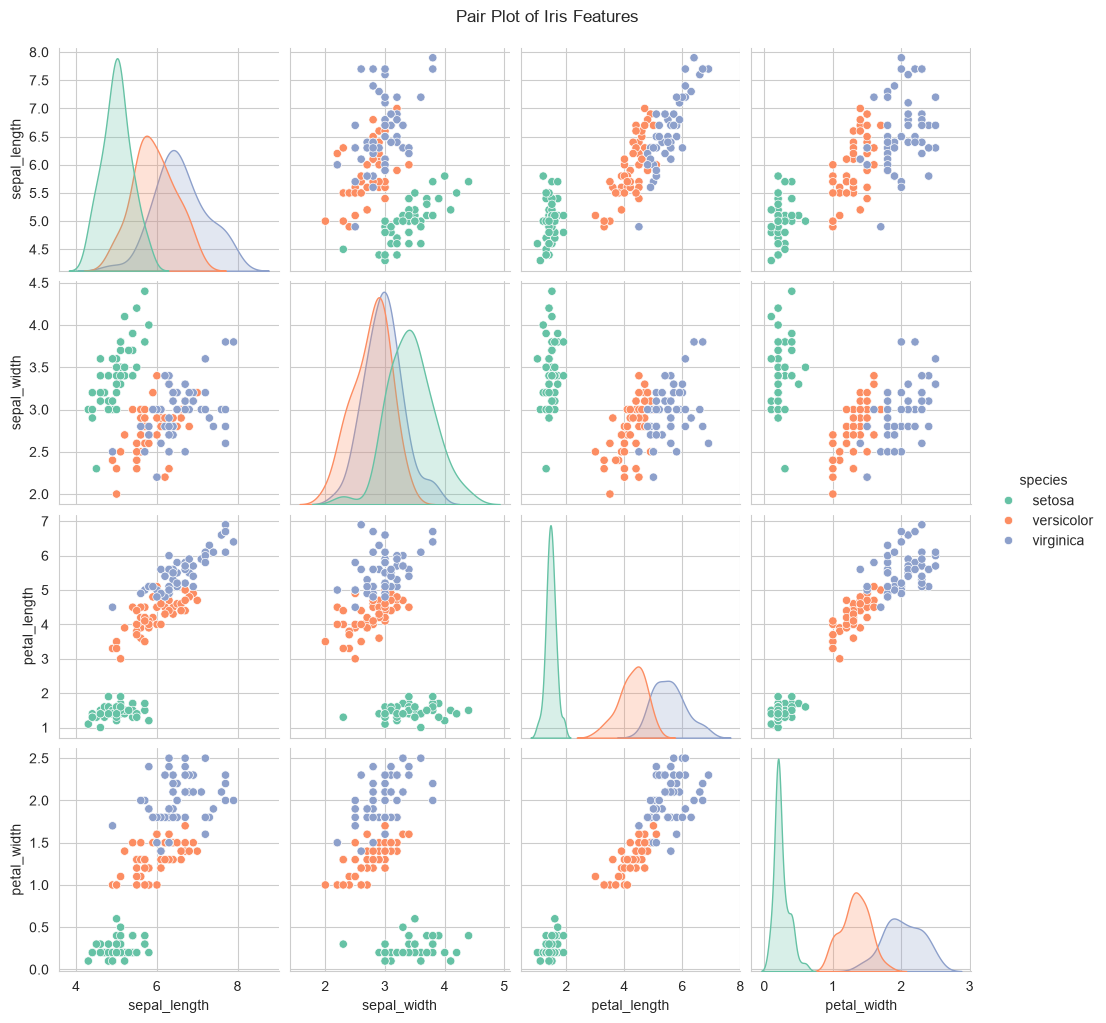

In [23]:
sns.pairplot(iris, hue='species', diag_kind='kde', palette='Set2')
import matplotlib.pyplot as plt
plt.suptitle('Pair Plot of Iris Features', y=1.02)
plt.show()

## 6. Key Findings

1. **No missing values** and 1 duplicate row — dataset is clean.
2. **Setosa** is clearly separable from the other two species, especially by petal features.
3. **Petal length and petal width** have the highest positive correlation (~0.96).
4. **Versicolor and Virginica** overlap more, making them harder to distinguish.
5. **Sepal width** is the only feature where Setosa has higher values than the others.